# Topic  : Mood-based clustering (unsupervised)

## Problem Statement

Without using genre labels at all, can songs be grouped into meaningful 'mood' clusters based on their audio DNA This project applies unsupervised clustering (K-Means/DBSCAN) to audio features to discover natural groupings of tracks, then interprets each cluster's dominant characteristics  e.g., 'high energy + low valence = intense/dark'  as a foundation for a mood-based playlist generator.

## Data Info
Data Source :https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs

## Data Dictionary
| Column | Type | Description |
|---|---|---|
| track_id | string | Spotify track ID |
| track_name | string | Song title |
| track_artist | string | Performing artist |
| track_popularity | int | Spotify popularity score, 0–100 |
| track_album_id | string | Spotify album ID |
| track_album_name | string | Album title |
| track_album_release_date | string (date) | Album release date, 1957-01-01 to 2020-01-29 |
| playlist_name | string | Name of the playlist the track was pulled from |
| playlist_id | string | Spotify playlist ID |
| playlist_genre | string | One of: pop, rap, rock, latin, r&b, edm |
| playlist_subgenre | string | One of 24 subgenres nested under the 6 genres |
| danceability | float | 0.0–1.0, how suitable the track is for dancing |
| energy | float | 0.0–1.0, perceptual intensity/activity |
| key | int | Musical key, 0–11 (pitch class notation, 0=C) |
| loudness | float | Overall loudness in dB |
| mode | int (0/1) | Modality — 1 = major, 0 = minor |
| speechiness | float | 0.0–1.0, presence of spoken words |
| acousticness | float | 0.0–1.0, confidence the track is acoustic |
| instrumentalness | float | 0.0–1.0, predicts absence of vocals |
| liveness | float | 0.0–1.0, likelihood the track was performed live |
| valence | float | 0.0–1.0, musical positiveness (happy vs. sad) |
| tempo | float | Estimated tempo in BPM |
| duration_ms | int | Track length in milliseconds (4,000–517,810) |

# Importing

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import joblib
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# Loading the data set

In [30]:
df2 = pd.read_csv(r'C:\Users\jojah\GA_DSB\capstone project\second topic\spotify\spotify_songs.csv')
df2.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


# No target column here since this is unsupervised 
 the goal is to pick a clean, comparable set of 'mood DNA' features before running K-Means/DBSCAN, and check for redundancy between them.

In [31]:
dna_feats = ['energy', 'valence', 'danceability', 'acousticness', 'loudness', 'tempo', 'mode']
df2[dna_feats].describe().T[['min', 'max', 'mean', 'std']]

,min,max,mean,std
energy,0.000175,1.000,0.698619,0.180910
valence,0.000000,0.991,0.510561,0.233146
danceability,0.000000,0.983,0.654850,0.145085
acousticness,0.000000,0.994,0.175334,0.219633
loudness,-46.448000,1.275,-6.719499,2.988436
tempo,0.000000,239.440,120.881132,26.903624
mode,0.000000,1.000,0.565711,0.495671


**Candidate DNA features:** `energy` + `valence` are the two core mood axes (this is basically the valence-arousal model of mood) — energy/dark example in the problem statement is literally high energy + low valence. `danceability` and `acousticness` add useful texture, `loudness`/`tempo` add intensity, `mode` (major/minor) adds a weak happy/sad signal.

**Scale mismatch is the first problem:** `loudness` ranges roughly -46 to +1 dB, `tempo` ranges 0-239 BPM, everything else is 0-1. K-Means/DBSCAN use Euclidean distance, so without scaling, loudness and tempo would completely dominate the clustering.

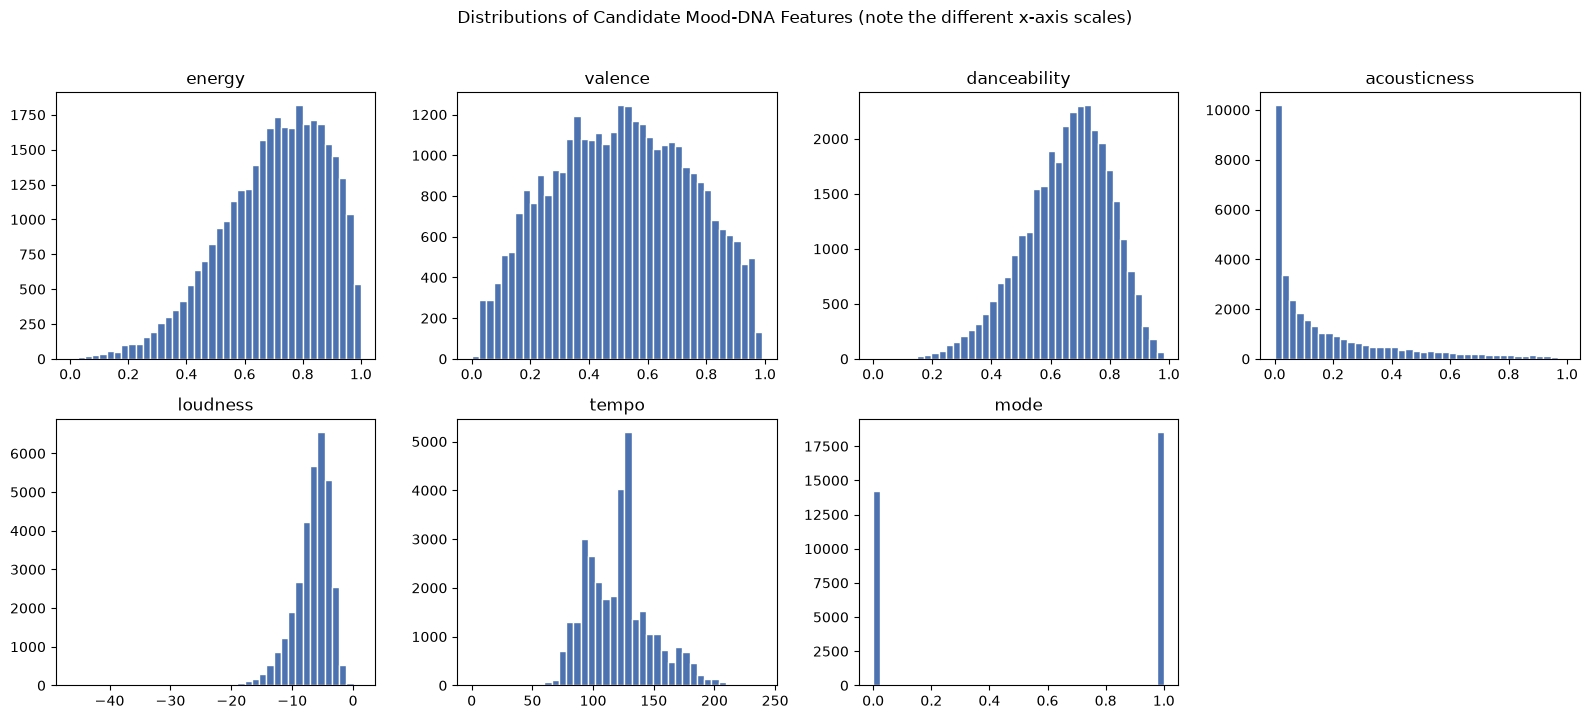

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(16,7))
axes = axes.flatten()
for i, c in enumerate(dna_feats):
    axes[i].hist(df2[c], bins=40, color='#4C72B0', edgecolor='white')
    axes[i].set_title(c)
axes[-1].axis('off')
plt.suptitle('Distributions of Candidate Mood-DNA Features (note the different x-axis scales)', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\jojah\AppData\Local\Temp\ipykernel_27084\2375617535.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot([df2[c] for c in dna_feats], tick_labels=dna_feats, vert=True)


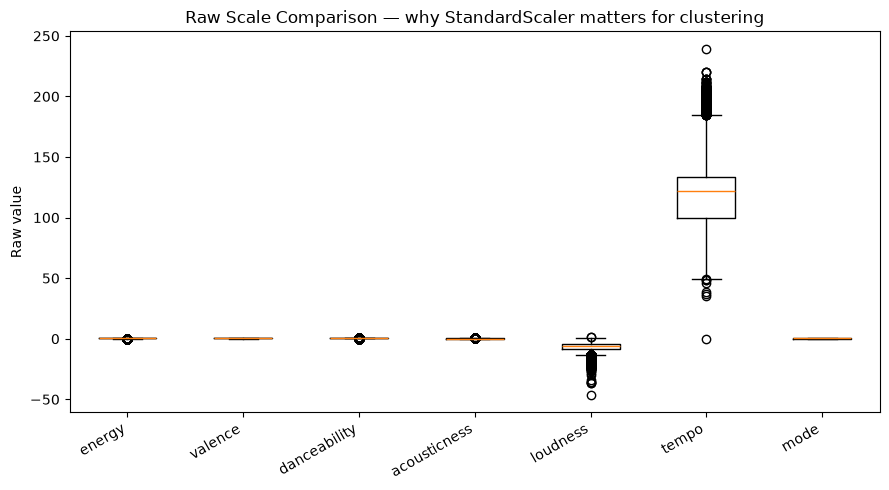

In [33]:
fig, ax = plt.subplots(figsize=(9,5))
ax.boxplot([df2[c] for c in dna_feats], tick_labels=dna_feats, vert=True)
ax.set_title('Raw Scale Comparison — why StandardScaler matters for clustering')
ax.set_ylabel('Raw value')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Plan:** run `StandardScaler` on all 7 features before clustering — the boxplot above makes it obvious `loudness` and `tempo` live on a totally different scale than the rest.

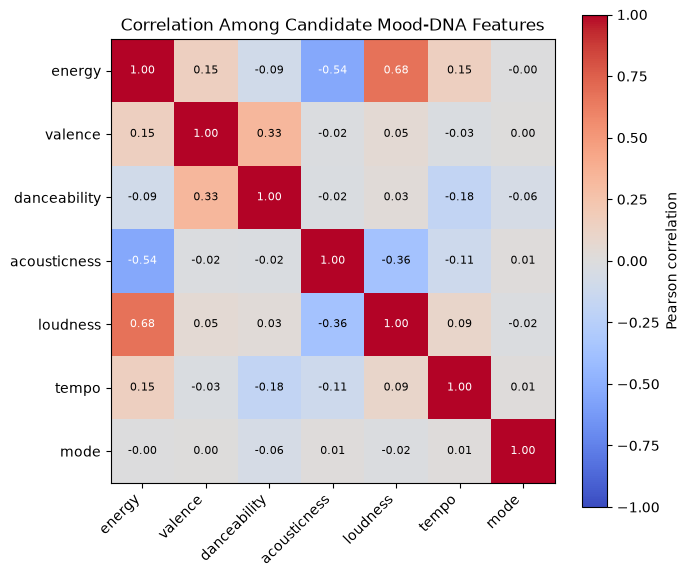

In [34]:
corr = df2[dna_feats].corr()

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(dna_feats))); ax.set_yticks(range(len(dna_feats)))
ax.set_xticklabels(dna_feats, rotation=45, ha='right')
ax.set_yticklabels(dna_feats)
for i in range(len(dna_feats)):
    for j in range(len(dna_feats)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center',
                 color='white' if abs(corr.values[i,j])>0.5 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Correlation Among Candidate Mood-DNA Features')
plt.tight_layout()
plt.show()

**Redundancy check:** `energy` and `loudness` correlate at 0.68 the strongest pair here, and expected (louder tracks read as more energetic). Everything else is fairly independent (|corr| < 0.4). Not severe enough to force dropping a feature, but worth knowing: those two will pull cluster boundaries in a similar direction. Either keep both and let PCA absorb the redundancy, or note it when interpreting cluster centers later.

# Finish EDA — duplicates & outliers

In [35]:
print("Duplicate track_ids:", df2['track_id'].duplicated().sum())
df2 = df2.drop_duplicates(subset='track_id').reset_index(drop=True)

outlier_summary = {}
for c in dna_feats:
    q1, q3 = df2[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_summary[c] = int(((df2[c] < lo) | (df2[c] > hi)).sum())
pd.Series(outlier_summary).sort_values(ascending=False)

Duplicate track_ids: 4477


acousticness    1911
loudness         837
tempo            494
danceability     257
energy           222
valence            0
mode               0
dtype: int64

# Scaling

In [47]:
# testing which scaler might be the best 

scalers = {
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler()
}

scaler_results = []
for name, sc in scalers.items():
    X_s = sc.fit_transform(df2[dna_feats])
    km = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
    labels = km.fit_predict(X_s)
    scaler_results.append({
        'scaler': name,
        'silhouette': silhouette_score(X_s, labels),
        'db_score': davies_bouldin_score(X_s, labels),
        'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
    })

pd.DataFrame(scaler_results)



,scaler,silhouette,db_score,cluster_sizes
0,RobustScaler,0.159970,1.741545,"{0: 8924, 1: 3780, 2: 6061, 3: 9591}"
1,StandardScaler,0.169057,1.661329,"{0: 4460, 1: 8930, 2: 7048, 3: 7918}"
2,MinMaxScaler,0.372537,1.108680,"{0: 7010, 1: 12321, 2: 6489, 3: 2536}"


In [48]:
df2['cluster'] = kmeans_labels
cluster_profile = df2.groupby('cluster')[dna_feats].mean()

acoustic_cluster_robust = cluster_profile['acousticness'].idxmax()
print("RobustScaler acoustic cluster:", acoustic_cluster_robust)

df2[df2['cluster'] == acoustic_cluster_robust][['track_name', 'track_artist'] + dna_feats].sample(15, random_state=42)

RobustScaler acoustic cluster: 1


,track_name,track_artist,energy,valence,danceability,acousticness,loudness,tempo,mode
5442,With U,SwuM,0.309,0.184,0.414,0.863,-11.858,90.026,0
19555,8,Billie Eilish,0.235,0.462,0.735,0.698,-13.239,62.446,1
5482,Sunset,Hyperparadise,0.200,0.506,0.669,0.934,-16.880,166.250,0
20045,Yo soy el punto cubano,David Blanco,0.547,0.274,0.500,0.364,-4.989,79.977,1
9066,Hit Me,Molotov,0.818,0.442,0.700,0.518,-7.623,90.041,0
2655,Firestone (feat. Conrad Sewell),Kygo,0.652,0.391,0.486,0.408,-7.226,113.055,0
15329,Deixa Eu Te Encontrar,Julia Sicone,0.488,0.518,0.641,0.398,-8.646,119.895,0
10190,Love Me,Lil Tecca,0.373,0.827,0.706,0.637,-12.610,204.031,0
23292,The Root,D'Angelo,0.410,0.704,0.866,0.498,-7.348,80.194,1
3979,Party City,Charlotte Rose Benjamin,0.693,0.678,0.562,0.427,-8.183,144.971,1


In [37]:
X_mm = MinMaxScaler().fit_transform(df2[dna_feats])
km_mm = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
mm_labels = km_mm.fit_predict(X_mm)
df2['mm_cluster'] = mm_labels
df2.groupby('mm_cluster')[dna_feats].mean()

# check to confim

,energy,valence,danceability,acousticness,loudness,tempo,mode
mm_cluster,,,,,,,
0,0.745180,0.718010,0.704376,0.125767,-6.478676,120.189141,1.0
1,0.699290,0.511212,0.662555,0.175458,-6.756431,120.442367,0.0
2,0.742709,0.324971,0.600381,0.068592,-6.173280,125.305133,1.0
3,0.451251,0.406897,0.603367,0.605469,-9.701367,114.444853,1.0


In [38]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df2[dna_feats])
X_scaled = pd.DataFrame(X_scaled, columns=dna_feats, index=df2.index)
X_scaled.describe().T[['min','max','mean','std']]

,min,max,mean,std
energy,-2.734186,1.053030,-0.089441,0.695087
valence,-1.398907,1.308743,-0.004408,0.640273
danceability,-3.366834,1.572864,-0.083556,0.732590
acousticness,-0.324478,3.722341,0.396848,0.907086
loudness,-11.162280,2.093188,-0.154627,0.843342
tempo,-3.585182,3.451583,-0.030471,0.792152
mode,-1.000000,0.000000,-0.434511,0.495701


# standard scaler 

In [45]:
scaler_std = StandardScaler()
X_scaled_std = scaler_std.fit_transform(df2[dna_feats])

kmeans_final_std = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
labels_std = kmeans_final_std.fit_predict(X_scaled_std)

df2['cluster_std'] = labels_std

cluster_profile_std = df2.groupby('cluster_std')[dna_feats].mean()
acoustic_cluster = cluster_profile_std['acousticness'].idxmax()
print("Acoustic cluster:", acoustic_cluster)

df2[df2['cluster_std'] == acoustic_cluster][['track_name', 'track_artist'] + dna_feats].sample(15, random_state=42)


Acoustic cluster: 0


,track_name,track_artist,energy,valence,danceability,acousticness,loudness,tempo,mode
3113,A Fuego Lento,Valeria,0.517,0.883,0.862,0.788,-11.343,118.980,1
13188,Hey There Delilah,Plain White T's,0.296,0.311,0.658,0.872,-10.584,103.975,1
12012,Walk on the Wild Side,Lou Reed,0.262,0.376,0.564,0.652,-19.746,104.500,1
23186,You're Everything,Sunny Hawkins,0.310,0.582,0.741,0.686,-8.705,80.991,0
15151,Right Now,Daxten,0.520,0.349,0.669,0.444,-10.661,108.975,1
23460,Bound,Ponderosa Twins Plus One,0.540,0.657,0.458,0.715,-6.457,142.218,0
23438,Who's Lovin' You,Michael Bublé,0.559,0.746,0.534,0.567,-5.220,69.878,1
10132,Dissociation,Aaryan Shah,0.212,0.128,0.317,0.583,-17.301,118.934,0
14310,Baba O'Riley - Remixed Version,The Who,0.668,0.129,0.405,0.436,-8.609,118.039,1
6240,Willpower,MAVI,0.749,0.353,0.503,0.622,-8.528,79.353,1


In [49]:
print("RobustScaler acoustic cluster valence std (full):", df2[df2['cluster'] == acoustic_cluster_robust]['valence'].std())
print("StandardScaler acoustic cluster valence std (full):", df2[df2['cluster_std'] == acoustic_cluster]['valence'].std())

RobustScaler acoustic cluster valence std (full): 0.22544769734739573
StandardScaler acoustic cluster valence std (full): 0.21122700579932144


# PCA

Explained variance: [0.36281636 0.18976303] total: 0.5525793948136629


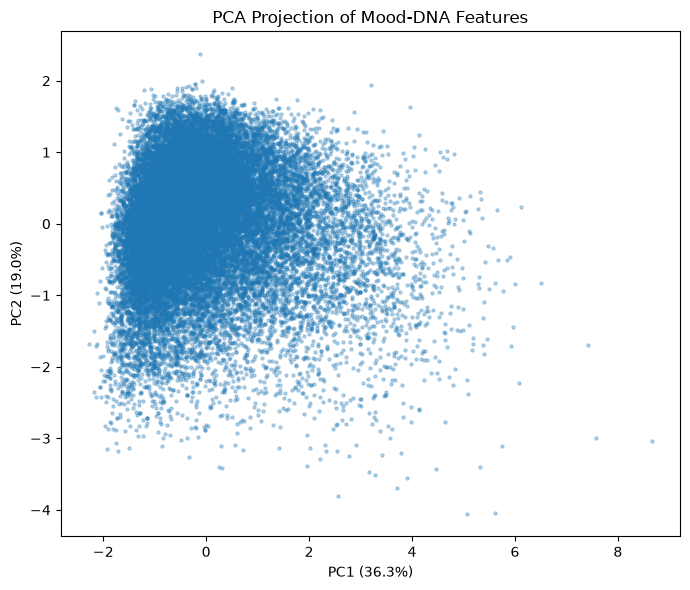

In [16]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_, "total:", pca.explained_variance_ratio_.sum())

plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=5, alpha=0.3)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA Projection of Mood-DNA Features')
plt.tight_layout()
plt.show()

# Pick K — elbow, silhouette, Davies-Bouldin

In [51]:
variants = {}
variants['Baseline (K=4)'] = X_scaled.copy()

X_weighted = X_scaled.copy()
X_weighted[['energy', 'valence']] *= 1.75
variants['Weighted energy/valence (K=4)'] = X_weighted

variants['No mode (K=4)'] = X_scaled.drop(columns='mode')

results = []
for name, X_v in variants.items():
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    labels = km.fit_predict(X_v)
    results.append({
        'variant': name,
        'silhouette': silhouette_score(X_v, labels),
        'db_score': davies_bouldin_score(X_v, labels),
        'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
    })

for k in [3, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    results.append({
        'variant': f'Baseline (K={k})',
        'silhouette': silhouette_score(X_scaled, labels),
        'db_score': davies_bouldin_score(X_scaled, labels),
        'cluster_sizes': pd.Series(labels).value_counts().sort_index().to_dict()
    })

pd.DataFrame(results)

,variant,silhouette,db_score,cluster_sizes
0,Baseline (K=4),0.159970,1.741545,"{0: 8924, 1: 3780, 2: 6061, 3: 9591}"
1,Weighted energy/valence (K=4),0.192434,1.551284,"{0: 8189, 1: 9775, 2: 7333, 3: 3059}"
2,No mode (K=4),0.177767,1.623538,"{0: 8848, 1: 9605, 2: 6116, 3: 3787}"
3,Baseline (K=3),0.172131,1.759846,"{0: 12875, 1: 4924, 2: 10557}"
4,Baseline (K=5),0.157846,1.669414,"{0: 3901, 1: 5367, 2: 8277, 3: 7254, 4: 3557}"


In [52]:
X_weighted = X_scaled.copy()
X_weighted[['energy', 'valence']] *= 1.75

km_weighted = KMeans(n_clusters=4, random_state=42, n_init=10)
weighted_labels = km_weighted.fit_predict(X_weighted)

df2['cluster_weighted'] = weighted_labels
df2.groupby('cluster_weighted')[dna_feats].mean()

,energy,valence,danceability,acousticness,loudness,tempo,mode
cluster_weighted,,,,,,,
0,0.842023,0.344946,0.566708,0.056809,-4.994777,129.766030,0.563683
1,0.776192,0.743256,0.714844,0.147060,-5.951027,119.273732,0.564501
2,0.563620,0.431323,0.693105,0.159199,-8.258739,116.310841,0.557480
3,0.388315,0.398673,0.593695,0.638730,-11.012664,113.884043,0.592677


In [53]:
df2[df2['cluster_weighted'] == 3][['track_name', 'track_artist'] + dna_feats].sample(15, random_state=42)

,track_name,track_artist,energy,valence,danceability,acousticness,loudness,tempo,mode
15863,Making Plans For Nigel,Nouvelle Vague,0.406,0.591,0.735,0.359,-12.390,119.984,1
3210,It Hurts (There Must Be a Taste of Murder in It),The Lotus Eaters,0.546,0.566,0.633,0.492,-13.437,129.663,0
11879,I Was Only Joking,Rod Stewart,0.462,0.415,0.680,0.583,-9.289,106.200,1
12543,Driftin' Blues,Charles Brown,0.239,0.494,0.342,0.853,-15.682,200.639,1
13463,Wouldn't It Be Nice - Stereo Mix,The Beach Boys,0.629,0.720,0.392,0.718,-7.056,124.511,1
1511,Colourblind,Tones and I,0.154,0.115,0.493,0.729,-9.996,98.380,0
23145,Good Love,Qendresa,0.214,0.339,0.821,0.763,-10.692,78.079,0
16301,Perdóname,Mau y Ricky,0.448,0.691,0.531,0.690,-7.747,87.883,0
4918,Howling,RY X,0.327,0.113,0.712,0.162,-13.860,119.983,0
12457,Happy Together,The Turtles,0.367,0.588,0.584,0.550,-9.638,120.175,0


In [54]:
df2[df2['cluster_weighted'] == 2][['track_name', 'track_artist'] + dna_feats].sample(15, random_state=42)

,track_name,track_artist,energy,valence,danceability,acousticness,loudness,tempo,mode
8802,Ghostface Killers,21 Savage,0.436,0.243,0.782,0.3310,-7.033,82.994,1
5923,Run,Lost Child,0.545,0.226,0.596,0.3560,-7.465,83.054,0
3698,Home (feat. Nico Santos),Topic,0.527,0.324,0.723,0.0267,-7.792,126.072,0
16245,Ni Un Fruto,Denise Rosenthal,0.524,0.461,0.596,0.0834,-8.755,165.854,0
7127,Feel It In The Air,Beanie Sigel,0.596,0.484,0.358,0.1470,-11.906,178.008,0
24699,Always There,Ben Rainey,0.682,0.257,0.655,0.0242,-9.749,124.027,0
19720,Bankroll,Sy Ari Da Kid,0.639,0.449,0.858,0.2660,-6.777,127.982,1
15098,Pánico Cero,King Edi K,0.611,0.546,0.802,0.3560,-7.521,105.001,1
16441,Music of My Heart,*NSYNC,0.556,0.398,0.375,0.3980,-7.201,111.824,1
22066,Caught Up,Teedra Moses,0.457,0.819,0.720,0.2160,-7.999,97.089,0


In [55]:
print("Cluster 3 full valence std:", df2[df2['cluster_weighted'] == 3]['valence'].std())

Cluster 3 full valence std: 0.21566973162299094


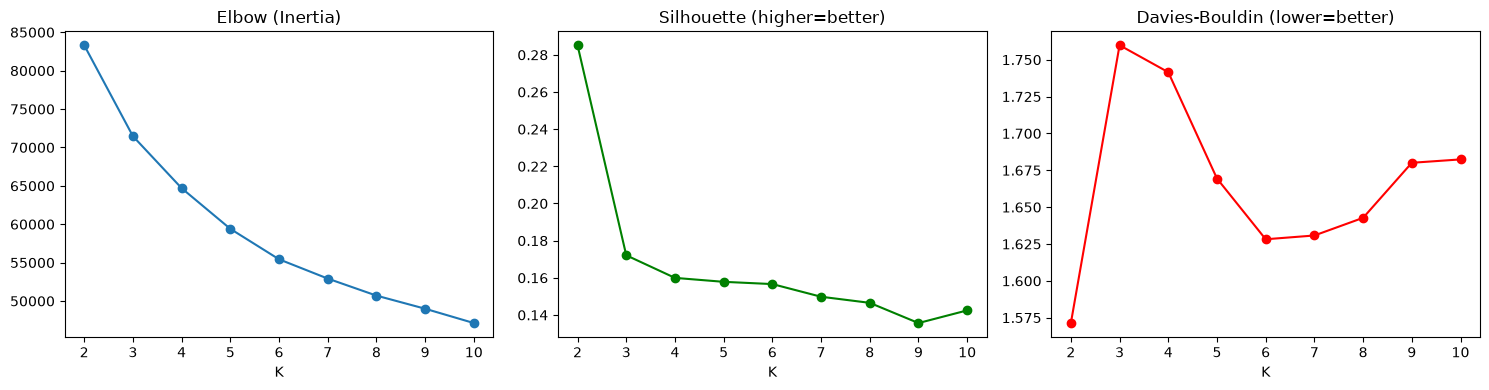

Best K by silhouette: 2


In [17]:
inertias, sils, dbs = [], [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))
    dbs.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].plot(K_range, inertias, 'o-'); axes[0].set_title('Elbow (Inertia)'); axes[0].set_xlabel('K')
axes[1].plot(K_range, sils, 'o-', color='green'); axes[1].set_title('Silhouette (higher=better)'); axes[1].set_xlabel('K')
axes[2].plot(K_range, dbs, 'o-', color='red'); axes[2].set_title('Davies-Bouldin (lower=better)'); axes[2].set_xlabel('K')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sils))]
print("Best K by silhouette:", best_k)

In [18]:
FINAL_K = 4  # domain-driven choice, not the silhouette argmax — see writeup note

kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

print(f"K=2 (silhouette-optimal): {sils[0]:.3f}")
print(f"K={FINAL_K} (chosen):     {silhouette_score(X_scaled, kmeans_labels):.3f}")
print("Cluster sizes:", pd.Series(kmeans_labels).value_counts().sort_index().to_dict())

K=2 (silhouette-optimal): 0.285
K=4 (chosen):     0.160
Cluster sizes: {0: 8924, 1: 3780, 2: 6061, 3: 9591}


In [50]:
df2['cluster'] = kmeans_labels
cluster_profile = df2.groupby('cluster')[dna_feats].mean()
cluster_profile['track_count'] = df2['cluster'].value_counts().sort_index()

def label_mood(cluster_profile):
    e_med = cluster_profile['energy'].median()
    v_med = cluster_profile['valence'].median()

    def label_row(row):
        if row['energy'] >= e_med and row['valence'] >= v_med:
            base = "Upbeat / Hype"
        elif row['energy'] >= e_med and row['valence'] < v_med:
            base = "Intense / Dark"
        elif row['energy'] < e_med and row['valence'] >= v_med:
            base = "Chill / Feel-Good"
        else:
            base = "Chill / Melancholic"
        if row['acousticness'] > 0.3:  # absolute floor — acousticness itself is meaningful in absolute terms
            base += " (Acoustic)"
        return base

    return cluster_profile.apply(label_row, axis=1)


cluster_profile['mood_label'] = label_mood(cluster_profile)
mood_lookup = cluster_profile['mood_label'].to_dict()
cluster_profile

,energy,valence,danceability,acousticness,loudness,tempo,mode,track_count,mood_label
cluster,,,,,,,,,
0,0.819469,0.405504,0.550343,0.064692,-5.100605,139.086298,0.574070,8924,Intense / Dark
1,0.455499,0.431974,0.607546,0.637685,-9.880887,114.206839,0.588095,3780,Chill / Melancholic (Acoustic)
2,0.562125,0.478800,0.695707,0.121209,-9.645386,115.824916,0.561129,6061,Chill / Feel-Good
3,0.767564,0.658840,0.740544,0.135710,-5.421160,109.989641,0.551350,9591,Upbeat / Hype


# DBSCAN

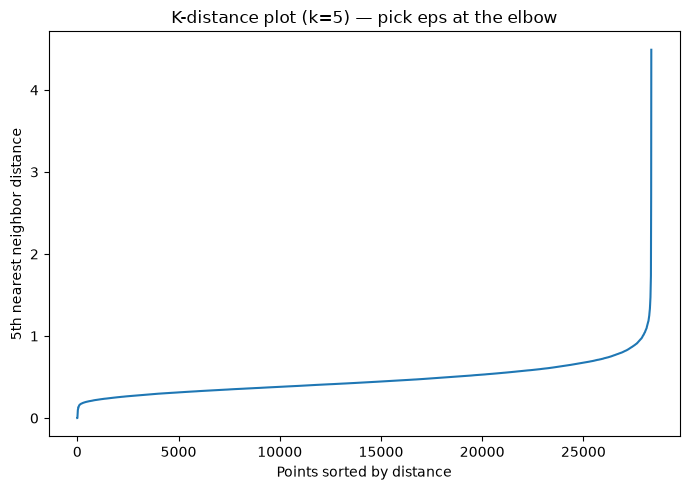

In [10]:
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.title('K-distance plot (k=5) — pick eps at the elbow')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th nearest neighbor distance')
plt.tight_layout()
plt.show()

In [11]:
dbscan = DBSCAN(eps=0.85, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
print(f"DBSCAN found {n_clusters_db} clusters, {n_noise} noise points ({n_noise/len(db_labels)*100:.1f}%)")
print("Cluster sizes:", pd.Series(db_labels).value_counts().sort_index().to_dict())

if n_clusters_db >= 2:
    mask = db_labels != -1
    print("Silhouette (excl. noise):", silhouette_score(X_scaled[mask], db_labels[mask]))
    print("Davies-Bouldin (excl. noise):", davies_bouldin_score(X_scaled[mask], db_labels[mask]))

DBSCAN found 7 clusters, 435 noise points (1.5%)
Cluster sizes: {-1: 435, 0: 15814, 1: 12084, 2: 5, 3: 2, 4: 5, 5: 7, 6: 4}
Silhouette (excl. noise): 0.030809340624971992
Davies-Bouldin (excl. noise): 1.5599920116380346


# Agglomerative

In [13]:
K_range = range(2, 11)

agg_results = []
for k in K_range:
    agg = AgglomerativeClustering(n_clusters=k)
    labels = agg.fit_predict(X_scaled)
    agg_results.append({
        'k': k,
        'silhouette': silhouette_score(X_scaled, labels),
        'db_score': davies_bouldin_score(X_scaled, labels)
    })

pd.DataFrame(agg_results)

,k,silhouette,db_score
0,2,0.329271,1.363790
1,3,0.131847,1.969906
2,4,0.105905,1.869636
3,5,0.098652,1.935324
4,6,0.092082,1.970055
5,7,0.084534,2.004722
6,8,0.082389,2.085495
7,9,0.080631,2.022115
8,10,0.075332,2.007335


In [19]:
FINAL_K = 4
agg_final = AgglomerativeClustering(n_clusters=FINAL_K)
agg_labels = agg_final.fit_predict(X_scaled)

print(f"K-Means  silhouette: {silhouette_score(X_scaled, kmeans_labels):.3f}, DB: {davies_bouldin_score(X_scaled, kmeans_labels):.3f}")
print(f"Agglom.  silhouette: {silhouette_score(X_scaled, agg_labels):.3f}, DB: {davies_bouldin_score(X_scaled, agg_labels):.3f}")
print("Agglomerative cluster sizes:", pd.Series(agg_labels).value_counts().sort_index().to_dict())

K-Means  silhouette: 0.160, DB: 1.742
Agglom.  silhouette: 0.106, DB: 1.870
Agglomerative cluster sizes: {0: 15224, 1: 3123, 2: 2976, 3: 7033}


# GMM

In [56]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)
print("GMM silhouette:", silhouette_score(X_scaled, gmm_labels))
print("GMM DB:", davies_bouldin_score(X_scaled, gmm_labels))
print("GMM cluster sizes:", pd.Series(gmm_labels).value_counts().sort_index().to_dict())

GMM silhouette: 0.021205529399824594
GMM DB: 3.1219876189823137
GMM cluster sizes: {0: 8729, 1: 5524, 2: 7433, 3: 6670}


# Single-track functions

In [23]:
def preprocess_pipeline(df, feature_cols=dna_feats):
    return df[feature_cols].copy()

def predict_track_mood(track_features, scaler=scaler, model=kmeans_final, feature_cols=dna_feats, mood_lookup=mood_lookup):
    x = pd.DataFrame([track_features])[feature_cols]
    x_scaled = scaler.transform(x)
    x_scaled_df = pd.DataFrame(x_scaled, columns=feature_cols)
    cluster_id = int(model.predict(x_scaled_df)[0])
    return cluster_id, mood_lookup.get(cluster_id, "Unknown"), x_scaled[0]

radar_bounds = df2[dna_feats].agg(['min', 'max'])

def _normalize_for_radar(feature_dict):
    return [(feature_dict[c] - radar_bounds.loc['min', c]) / (radar_bounds.loc['max', c] - radar_bounds.loc['min', c])
            for c in dna_feats]

def visualize_track_vs_cluster(track_features, cluster_id, feature_cols=dna_feats, cluster_profile=cluster_profile):
    track_vals = _normalize_for_radar(track_features)
    cluster_vals = _normalize_for_radar(cluster_profile.loc[cluster_id, feature_cols].to_dict())
    angles = np.linspace(0, 2*np.pi, len(feature_cols), endpoint=False).tolist()
    track_vals += track_vals[:1]; cluster_vals += cluster_vals[:1]; angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    ax.plot(angles, track_vals, 'o-', linewidth=2, label='This track', color='#1DB954')
    ax.fill(angles, track_vals, alpha=0.25, color='#1DB954')
    ax.plot(angles, cluster_vals, 'o-', linewidth=2, label=f'Cluster {cluster_id} avg', color='#535353')
    ax.fill(angles, cluster_vals, alpha=0.15, color='#535353')
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(feature_cols)
    ax.set_title(f"Track vs. Cluster {cluster_id} ({mood_lookup.get(cluster_id)})")
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout(); plt.show()

CLUSTER_COLORS = ['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(mood_lookup)]

def plot_track_in_pca_space(track_features, cluster_id, X_pca=X_pca, cluster_labels=kmeans_labels, scaler=scaler, pca=pca, feature_cols=dna_feats, mood_lookup=mood_lookup):
    track_scaled = scaler.transform(pd.DataFrame([track_features])[feature_cols])
    track_pca = pca.transform(pd.DataFrame(track_scaled, columns=feature_cols))

    plt.figure(figsize=(8,7))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=[CLUSTER_COLORS[l] for l in cluster_labels], s=6, alpha=0.3)
    plt.scatter(track_pca[0,0], track_pca[0,1], c='red', s=250, marker='*', edgecolors='black', linewidths=1.5, zorder=5)
    handles = [mpatches.Patch(color=CLUSTER_COLORS[cid], label=mood_lookup[cid]) for cid in sorted(mood_lookup)]
    handles.append(plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='red', markeredgecolor='black', markersize=15, label='Your track'))
    plt.legend(handles=handles, loc='best')
    plt.xlabel('PC1'); plt.ylabel('PC2')
    plt.title(f'Track Location in Mood Space — Cluster {cluster_id} ({mood_lookup.get(cluster_id)})')
    plt.tight_layout(); plt.show()


def generate_mood_playlist(track_features, cluster_id, num_tracks=10, df=df2, X_scaled=X_scaled, scaler=scaler, feature_cols=dna_feats, exclude_track_id=None):
    track_scaled = scaler.transform(pd.DataFrame([track_features])[feature_cols])
    cluster_indices = df[df['cluster'] == cluster_id].index
    cluster_X = X_scaled.loc[cluster_indices]
    dists = euclidean_distances(track_scaled, cluster_X)[0]
    dist_series = pd.Series(dists, index=cluster_indices).sort_values()
    if exclude_track_id is not None and exclude_track_id in df['track_id'].values:
        dist_series = dist_series.drop(df[df['track_id'] == exclude_track_id].index, errors='ignore')
    top_idx = dist_series.head(num_tracks).index
    playlist = df.loc[top_idx, ['track_name', 'track_artist', 'cluster']].copy()
    playlist['distance'] = dist_series.head(num_tracks).values
    return playlist.reset_index(drop=True)

# Full demo

Predicted mood: Upbeat / Hype (cluster 3)


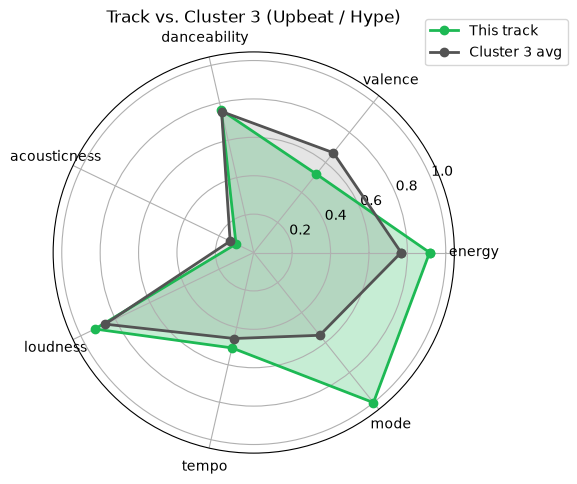

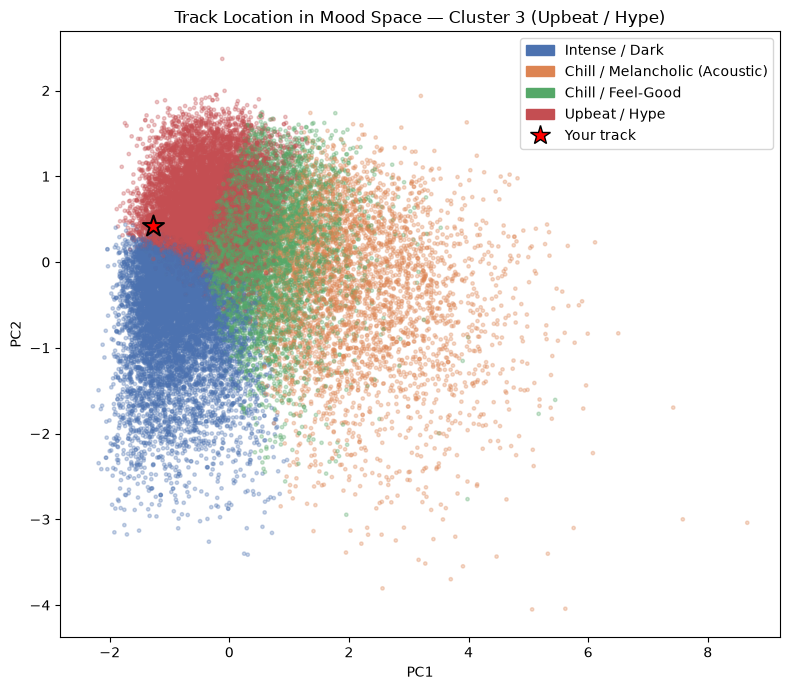

,track_name,track_artist,cluster,distance
0,Do It Again,Steve Aoki,3,0.323883
1,Lettin Go! (Album Version),Janelle Monáe,3,0.328162
2,Blah Blah Blah (feat. 3OH!3),Kesha,3,0.351305
3,You Got That,LOUD ABOUT US!,3,0.362285
4,Where Is the Love,Alex Martura,3,0.391980
5,As If It's Your Last,BLACKPINK,3,0.392656
6,Don’t Stop (feat. RayRay),Curbi,3,0.418399
7,Ontas (Te Pago El Uber),Leandro Da Silva,3,0.425785
8,Rise - TV Noise Ibiza Mix,Jonas Blue,3,0.427042
9,On Replay,Costa Leon,3,0.445592


In [24]:
def analyze_track(track_features, exclude_track_id=None, num_playlist=10):
    cluster_id, mood_label, _ = predict_track_mood(track_features)
    print(f"Predicted mood: {mood_label} (cluster {cluster_id})")
    visualize_track_vs_cluster(track_features, cluster_id)
    plot_track_in_pca_space(track_features, cluster_id)
    return cluster_id, mood_label, generate_mood_playlist(track_features, cluster_id, num_tracks=num_playlist, exclude_track_id=exclude_track_id)

example = df2.iloc[0][dna_feats].to_dict()
cluster_id, mood_label, playlist = analyze_track(example, exclude_track_id=df2.iloc[0]['track_id'])
playlist

# Export artifacts

In [26]:
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(kmeans_final, 'model.joblib')
joblib.dump(pca, 'pca.joblib')
joblib.dump(mood_lookup, 'mood_lookup.joblib')
joblib.dump(cluster_profile, 'cluster_profile.joblib')
joblib.dump(radar_bounds, 'radar_bounds.joblib')

['radar_bounds.joblib']

In [28]:

class MoodPipeline:
    def __init__(self, artifact_dir='.'):
        self.scaler = joblib.load(f'{artifact_dir}/scaler.joblib')
        self.model = joblib.load(f'{artifact_dir}/model.joblib')
        self.pca = joblib.load(f'{artifact_dir}/pca.joblib')
        self.mood_lookup = joblib.load(f'{artifact_dir}/mood_lookup.joblib')
        self.cluster_profile = joblib.load(f'{artifact_dir}/cluster_profile.joblib')
        self.radar_bounds = joblib.load(f'{artifact_dir}/radar_bounds.joblib')
        self.feature_cols = [c for c in self.cluster_profile.columns if c not in ('mood_label', 'track_count')]

    def predict_track_mood(self, track_features):
        x = pd.DataFrame([track_features])[self.feature_cols]
        x_scaled = pd.DataFrame(self.scaler.transform(x), columns=self.feature_cols)
        cluster_id = int(self.model.predict(x_scaled)[0])
        return cluster_id, self.mood_lookup.get(cluster_id, 'Unknown')

    def radar_data(self, track_features, cluster_id):
        norm = lambda d: {c: (d[c] - self.radar_bounds.loc['min', c]) / (self.radar_bounds.loc['max', c] - self.radar_bounds.loc['min', c]) for c in self.feature_cols}
        return norm(track_features), norm(self.cluster_profile.loc[cluster_id, self.feature_cols].to_dict())

    def generate_playlist(self, track_features, cluster_id, df, X_scaled, num_tracks=10, exclude_track_id=None):
        x = pd.DataFrame([track_features])[self.feature_cols]
        track_scaled = self.scaler.transform(x)
        cluster_indices = df[df['cluster'] == cluster_id].index
        dists = euclidean_distances(track_scaled, X_scaled.loc[cluster_indices])[0]
        dist_series = pd.Series(dists, index=cluster_indices).sort_values()
        if exclude_track_id is not None and exclude_track_id in df['track_id'].values:
            dist_series = dist_series.drop(df[df['track_id'] == exclude_track_id].index, errors='ignore')
        top_idx = dist_series.head(num_tracks).index
        out = df.loc[top_idx, ['track_name', 'track_artist', 'cluster']].copy()
        out['distance'] = dist_series.head(num_tracks).values
        return out.reset_index(drop=True)